### A Dog on a Leash? (Part 1)

The Heating Oil and Natural Gas prices are pre-loaded in DataFrames HO and NG. First, plot both price series, which look like random walks. Then plot the difference between the two series, which should look more like a mean reverting series (to put the two series in the same units, we multiply the heating oil prices, in dollars/gallon, by 7.25, which converts it to dollars/millionBTU, which is the same units as Natural Gas).

- Plot Heating Oil, HO, and Natural Gas, NG, on the same subplot
    - Make sure you multiply the HO price by 7.25 to match the units of NG
- Plot the spread on a second subplot
    - The spread will be 7.25*HO - NG

In [ ]:
# Plot the prices separately
plt.subplot(2,1,1)
plt.plot(7.25*HO, label='Heating Oil')
plt.plot(NG, label='Natural Gas')
plt.legend(loc='best', fontsize='small')

# Plot the spread
plt.subplot(2,1,2)
plt.plot(7.25*HO-NG, label='Spread')
plt.legend(loc='best', fontsize='small')
plt.axhline(y=0, linestyle='--', color='k')
plt.show()

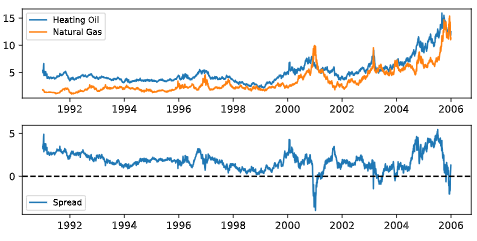

### A Dog on a Leash? (Part 2)
To verify that Heating Oil and Natural Gas prices are cointegrated, First apply the Dickey-Fuller test separately to show they are random walks. Then apply the test to the difference, which should strongly reject the random walk hypothesis. The Heating Oil and Natural Gas prices are pre-loaded in DataFrames HO and NG.

- Perform the adfuller test on HO and on NG separately, and save the results (results are a list)
    - The argument for adfuller must be a series, so you need to include the column 'Close'
    - Print just the p-value (item [1] in the list)
- Do the same thing for the spread, again converting the units of HO, and using the column 'Close' of each DataFrame

In [ ]:
# Import the adfuller module from statsmodels
from statsmodels.tsa.stattools import adfuller

# Compute the ADF for HO and NG
result_HO = adfuller(HO['Close'])
print("The p-value for the ADF test on HO is ", result_HO[1])
result_NG = adfuller(NG['Close'])
print("The p-value for the ADF test on NG is ", result_NG[1])

# Compute the ADF of the spread
result_spread = adfuller(7.25 * HO-NG)
print("The p-value for the ADF test on the spread is ", result_spread[1])


The p-value for the ADF test on HO is  0.9567108785017872
The p-value for the ADF test on NG is  0.9008747444676731
The p-value for the ADF test on the spread is  7.019439302142287e-05

### Are Bitcoin and Ethereum Cointegrated?
Cointegration involves two steps: regressing one time series on the other to get the cointegration vector, and then perform an ADF test on the residuals of the regression. In the last example, there was no need to perform the first step since we implicitly assumed the cointegration vector was (1,-1). In other words, we took the difference between the two series (after doing a units conversion). Here, you will do both steps.

You will regress the value of one cryptocurrency, bitcoin (BTC), on another cryptocurrency, ethereum (ETH). If we call the regression coefficient b, then the cointegration vector is simply (1,-b). Then perform the ADF test on BTC -b ETH. Bitcoin and Ethereum prices are pre-loaded in DataFrames BTC and ETH.

- Import the statsmodels module for regression and the adfuller function
- Add a constant to the ETH DataFrame using sm.add_constant()
- Regress BTC on ETH using sm.OLS(y,x).fit(), where y is the dependent variable and x is the independent variable, and save the results in result.
    - The intercept is in result.params[0] and the slope in result.params[1]
- Run ADF test on BTC -b ETH

In [ ]:
# Import the statsmodels module for regression and the adfuller function
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Regress BTC on ETH
ETH = sm.add_constant(ETH)
result = sm.OLS(BTC,ETH).fit()

# Compute ADF
b = result.params[1]
adf_stats = adfuller(result['Price'] - b*result['Price'])
print("The p-value for the ADF test is ", adf_stats[1])

The p-value for the ADF test is  0.023369002323472707